<a href="https://colab.research.google.com/github/SofiaKakou/Customer_Churn_Prediction/blob/main/notebooks/05_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introduction
This notebook trains and evaluates ML Models for customer churn predictions.

Purpose:
- load the prepared test and training datasets
- train baseline model
- train advanced model
- evaluate model performance
- compare results
- select best performing model

# 2.Imports

In [1]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

import warnings
warnings.filterwarnings("ignore")


# 3.Load Dataset

In [2]:

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the prepared datasets
base_path = "/content/drive/MyDrive/Thesis/Prepared Data/"

x_train = pd.read_csv(base_path + "x_train.csv")
x_test = pd.read_csv(base_path + "x_test.csv")
y_train = pd.read_csv(base_path + "y_train.csv")
y_test = pd.read_csv(base_path + "y_test.csv")

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


x_train: (2132, 13)
x_test: (534, 13)
y_train: (2132, 1)
y_test: (534, 1)


In [4]:
# Confirming Target Distributon
print("Training Target Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True) * 100)


Training Target Distribution
Churn
False    85.459662
True     14.540338
Name: proportion, dtype: float64

Testing Target Distribution
Churn
False    85.393258
True     14.606742
Name: proportion, dtype: float64


# 4.Baseline Model | Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable and commonly used for binary classification problems.

The baseline model provides a reference point for comparing mode advanced models.

In [5]:
# Initialize and train
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(x_train, y_train)

# Predictions
y_pred_log = log_reg.predict(x_test)
y_prob_log = log_reg.predict_proba(x_test)[:, 1]

In [6]:
# Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.95      0.91       456
        True       0.39      0.18      0.25        78

    accuracy                           0.84       534
   macro avg       0.63      0.57      0.58       534
weighted avg       0.80      0.84      0.81       534



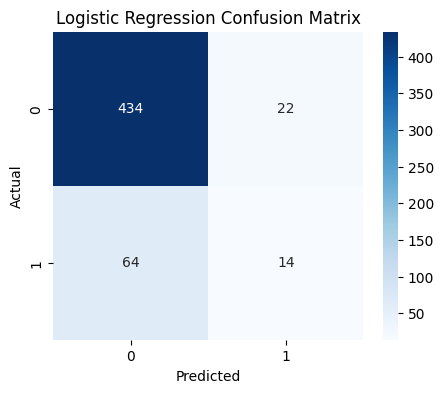

In [7]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Observations

- The model performs reasonably well in predicting non churn customers. However, its ability to correctly identify churned customers is more limited.
This reflected in lower recall for the churn class compared to non churn.

Overall, this provides a useful reference point but may struggle to capture complex patterns in the data.



# 5.Advanced Models
Two advanced models are trained and compared: Random Forest & XGBoost

- Random Forest: combined multiple decison trees & it can capture non linear relationships/ is robust to outlers.
- XGBoost: is known for strong predictive performance and it commonly used in tabular ML problems.

# 5.1Random Forest Model

Used for capturing non linear relationships and is robust to noise.

In [8]:
# Initialize & Train
rf = RandomForestClassifier (
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

# Predictions
y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:, 1]

In [9]:
# Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.99      0.97       456
        True       0.95      0.68      0.79        78

    accuracy                           0.95       534
   macro avg       0.95      0.84      0.88       534
weighted avg       0.95      0.95      0.94       534



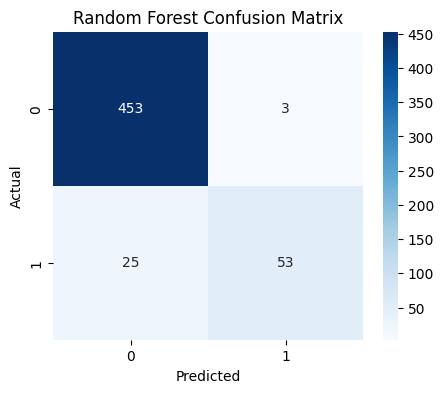

In [10]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Observations

The RF shows improved performance compared to the Logistic Regression.

- Higher overall accuracy and F1 Score
- Better Balance between precision and recall
- Improved ability to capture non linear relationships in the data

Random Forest is more effective at identifying churn patterns due to its structure and ability to model complex interactions between features.

# 5.2XGBoost Model

* Used due to its strong performance in structured data and ability to handle complex interactions

In [11]:
# Initialize & Train
xgb = XGBClassifier(
  eval_metric="logloss",
  random_state=42
)

xgb.fit(x_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:, 1]

In [12]:
# Evaluation
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.99      0.97       456
        True       0.93      0.73      0.82        78

    accuracy                           0.95       534
   macro avg       0.95      0.86      0.90       534
weighted avg       0.95      0.95      0.95       534



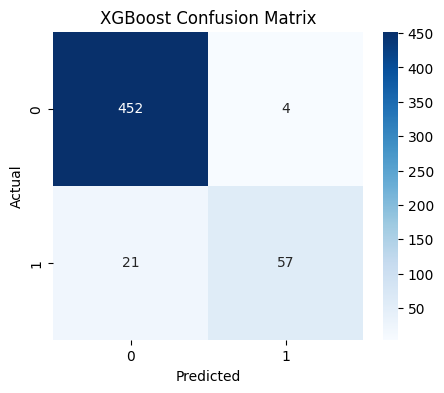

In [13]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Observations

- High predictive performance across multiple metrics
- Strong balance between precision and recall
- Effective handling of feature interactions and complex patterns

Its mechanism allows it to refine predictions iteratvely, leading to improved performance compared to more simple models


# 6.Model Evaluation & Comparison

Based on:
- Accuracy
- Precision
- Recall - churn cases identified
- F1-Score - balance between precision and recall
- ROC-AUC - ability to distinguish between churn and non churn customers

In [16]:
# Collecting model metrics
def evaluate_model(name, y_true, y_pred, y_prob):
  return {
      "Model": name,
      "Accuracy": accuracy_score(y_true, y_pred),
      "Precision": precision_score(y_true, y_pred),
      "Recall": recall_score(y_true, y_pred),
      "F1-Score": f1_score(y_true, y_pred),
      "ROC-AUC": roc_auc_score(y_true, y_prob)
  }

results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb))

results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.838951,0.388889,0.179487,0.245614,0.757535
1,Random Forest,0.947566,0.946429,0.679487,0.791045,0.880061
2,XGBoost,0.953184,0.934426,0.730769,0.820144,0.878233


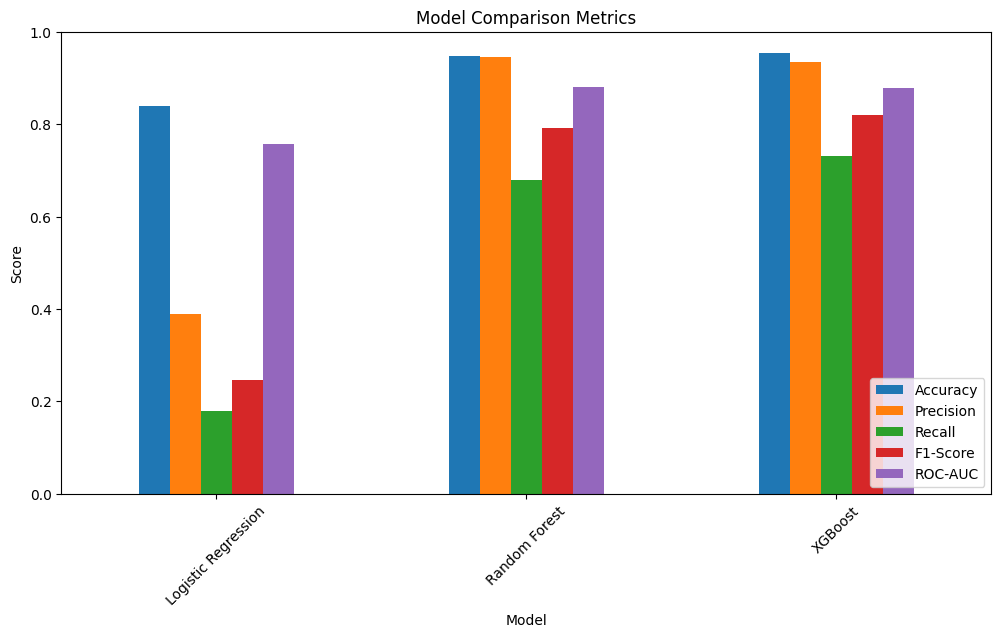

In [17]:
# Plot Model Comparison
results_df.set_index("Model")[["Accuracy",  "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", figsize=(12, 6))

plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()


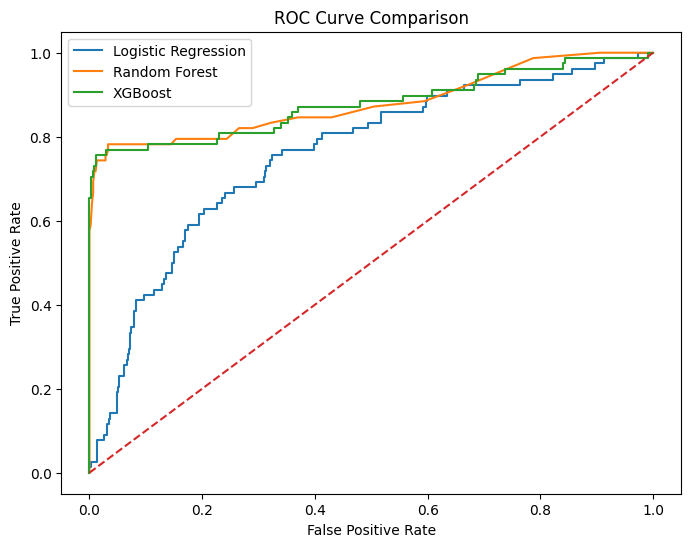

In [18]:
# ROC Curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Observations

The three models were compared using key evaluation metrics.

Overall findings:
- Logistic regression was limited in capturing complex patterns.
- Random Forest improved performance by handling non linear relationships
- XGBoost achieved the best overall performance across most metrics.

In churn prediction, recall is important because identifying customers at risk of leaving shows businesses to take preventive action.
Therefore models with higher recall for the churn class are considered more valuable.

# 7.Feature Importance
Feature importance helps identify which variables contribute most to model predictions.
This is useful for interpreting churn drivers and generating BI.

In [19]:
# Feature Importance (RF)
rf_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
4,Total day minutes,0.239494
12,Customer service calls,0.126690
1,International plan,0.093137
6,Total eve minutes,0.092747
10,Total intl minutes,0.077717
11,Total intl calls,0.068590
8,Total night minutes,0.065055
5,Total day calls,0.052007
9,Total night calls,0.051654
0,Account length,0.047827


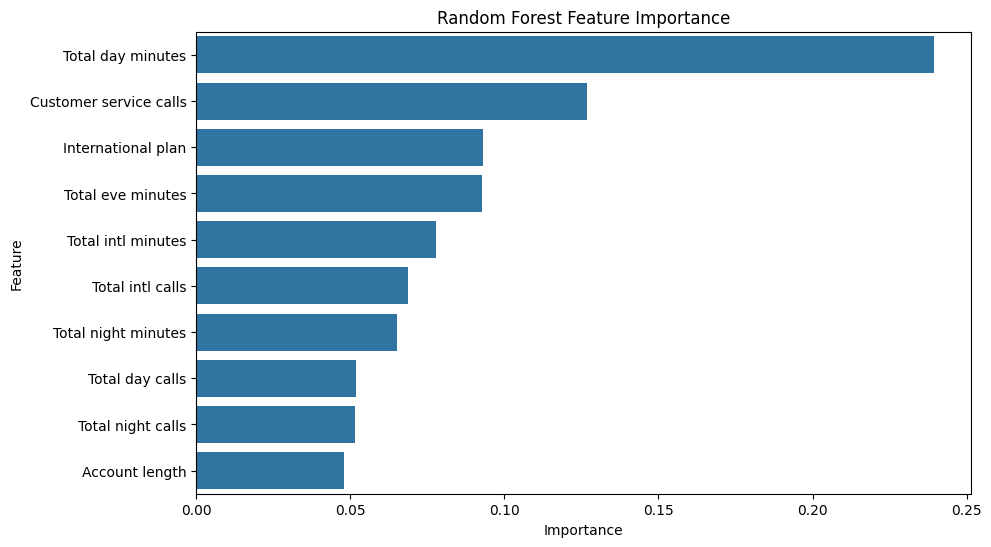

In [20]:
# Plot Feature Importance (RF)
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance", y="Feature", data=rf_importance.head(10))

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
# Feature Importance (XGBoost)

xgb_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(10)

,Feature,Importance
1,International plan,0.243200
12,Customer service calls,0.170132
2,Voice mail plan,0.131207
11,Total intl calls,0.100572
4,Total day minutes,0.092678
6,Total eve minutes,0.059607
10,Total intl minutes,0.055325
8,Total night minutes,0.030094
3,Number vmail messages,0.029033
9,Total night calls,0.027244


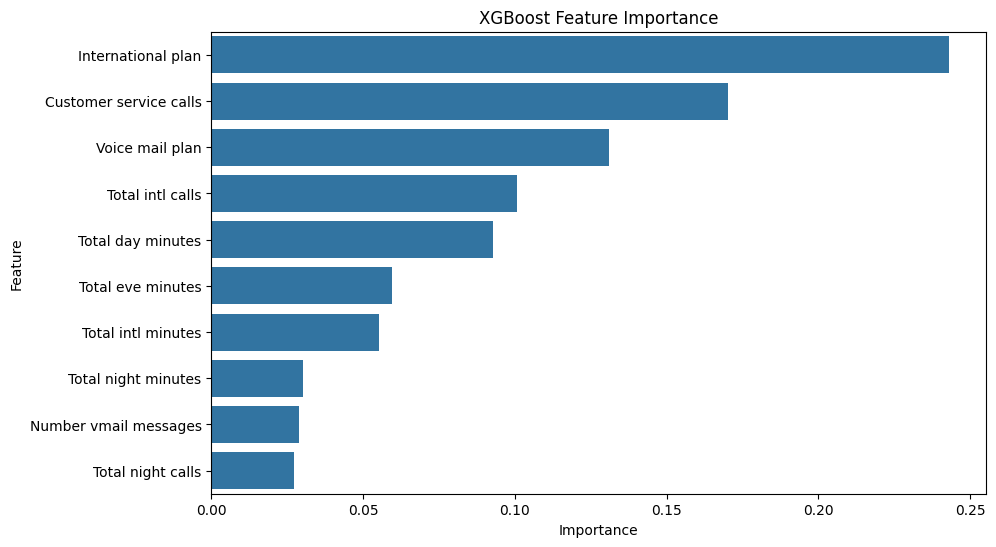

In [22]:
# Plot Feature Importance (XGBoost)
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance", y="Feature", data=xgb_importance.head(10))

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Observations

- Usage related features are strong predictors
- Customer service interactions play a significant role in churn behavior.
- Some features have minimal impact and may be less important

These findings align with earlier EDA insghts and help explain the models decision making process.

# 9.Model Selection

In [23]:
# Sort Models by F1 Score and ROC-AUC

results_df.sort_values(by=["F1-Score", "ROC-AUC"], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,XGBoost,0.953184,0.934426,0.730769,0.820144,0.878233
1,Random Forest,0.947566,0.946429,0.679487,0.791045,0.880061
0,Logistic Regression,0.838951,0.388889,0.179487,0.245614,0.757535


# 10.Conclusion

Based on all evaluation results, th e best performing model is the XGboost.
In the context of customer churn prediction, correctly identifying customers at risk is critical. there fore F1 Score and Recall were prioritized when selecting the final model.

This model will be used in the next stage for fuurther interpretation and analysis.